### Human gastruloid plots

In [82]:
import pandas as pd
import os
import json
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt
import pydeseq2 as deseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm

from custom_functions import *

save_format = "svg"

In [83]:
human_file = "../data/wnt_nodal_rnaseq/Human_gastruloids_bulk-Raw_counts.xlsx"  # replace with path

counts = pd.read_excel(human_file, index_col=1)
counts.drop(columns='gene_ID', inplace=True)
counts = counts.T

# kepp hESC, 0h and 24h
counts = counts[counts.index.str.contains(r'hESC|0h|24h')]

# Ensure counts are integers
counts = counts.fillna(0)  # Replace NaNs with 0
counts = counts.astype(int)

counts

gene_symbol,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC136297.1,BX248415.1,AL157886.1,AL392086.3,AL357123.1,AL589743.7,AL355312.5,AC120036.5,AC018931.1,AL731559.1
hESCs_r1,2715,74,1485,249,1114,6,1,1510,1618,1476,...,0,0,0,7,0,0,4,0,0,0
hESCs_r2,2076,48,1047,212,911,6,2,1153,1291,1226,...,0,0,0,8,0,0,6,0,0,0
hESCs_r3,2674,50,1201,242,978,3,0,1358,1660,1517,...,0,0,0,8,0,0,0,0,0,0
0h_r1,2080,62,1383,227,715,7,0,1383,989,1591,...,0,0,0,6,0,0,0,0,2,1
0h_r2,1955,81,1662,233,636,3,0,1544,1117,1579,...,0,0,0,16,0,0,0,0,0,0
0h_r3,2425,71,1749,294,882,4,0,1662,1251,1714,...,0,0,0,0,0,0,0,0,0,0
24h_r1,3623,38,2142,462,1416,7,0,1762,1404,2569,...,0,0,0,0,0,0,0,0,0,0
24h_r2,3513,53,2455,306,1049,0,0,1319,1371,1476,...,0,0,0,0,0,0,0,0,0,1
24h_r3,3312,34,2002,362,1297,0,1,1421,1299,1851,...,0,0,0,0,0,0,4,0,0,0


In [84]:
# metadata
# Correct metadata creation
metadata = pd.DataFrame({
    'condition': counts.index.to_series().apply(lambda x: x[:-3])
}, index=counts.index)

metadata.head()


,condition
hESCs_r1,hESCs
hESCs_r2,hESCs
hESCs_r3,hESCs
0h_r1,0h
0h_r2,0h


In [85]:
counts

gene_symbol,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC136297.1,BX248415.1,AL157886.1,AL392086.3,AL357123.1,AL589743.7,AL355312.5,AC120036.5,AC018931.1,AL731559.1
hESCs_r1,2715,74,1485,249,1114,6,1,1510,1618,1476,...,0,0,0,7,0,0,4,0,0,0
hESCs_r2,2076,48,1047,212,911,6,2,1153,1291,1226,...,0,0,0,8,0,0,6,0,0,0
hESCs_r3,2674,50,1201,242,978,3,0,1358,1660,1517,...,0,0,0,8,0,0,0,0,0,0
0h_r1,2080,62,1383,227,715,7,0,1383,989,1591,...,0,0,0,6,0,0,0,0,2,1
0h_r2,1955,81,1662,233,636,3,0,1544,1117,1579,...,0,0,0,16,0,0,0,0,0,0
0h_r3,2425,71,1749,294,882,4,0,1662,1251,1714,...,0,0,0,0,0,0,0,0,0,0
24h_r1,3623,38,2142,462,1416,7,0,1762,1404,2569,...,0,0,0,0,0,0,0,0,0,0
24h_r2,3513,53,2455,306,1049,0,0,1319,1371,1476,...,0,0,0,0,0,0,0,0,0,1
24h_r3,3312,34,2002,362,1297,0,1,1421,1299,1851,...,0,0,0,0,0,0,4,0,0,0


In [86]:
dds = DeseqDataSet(
    counts=counts.values,
    metadata=metadata,
    design_factors="condition",
    refit_cooks=False
)



In [87]:
dds.obs

,condition
hESCs_r1,hESCs
hESCs_r2,hESCs
hESCs_r3,hESCs
0h_r1,0h
0h_r2,0h
0h_r3,0h
24h_r1,24h
24h_r2,24h
24h_r3,24h


In [88]:
## Variance Stabilizing Transformation (VST)
#We scale the data normalizing the sum of total counts and producing and scaling to log1p.
# run vst algorithm
# transformed counts are stored in .layers
dds.vst(use_design=True)
# create df with transformed counts
df1= pd.DataFrame(data=dds.layers['vst_counts'],    
             index=dds.obs.index,    
            columns=counts.columns.values)

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 3.97 seconds.

Fitting dispersion trend curve...
... done in 0.46 seconds.



Genes retained: 1027


<Axes: >

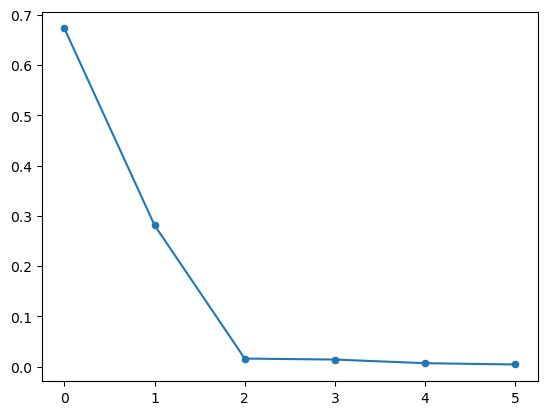

In [89]:
# Free parameters: **threshold**
fs = VarianceThreshold(threshold=0.5)
fs.fit(df1.values)
l1 = fs.get_feature_names_out()
l = [int(i[1:]) for i in l1]

print(f"Genes retained: {len(l)}")
## PCA
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=df1.columns.values[l])
pca = PCA(n_components=6)
pca.fit(df1_fs.values)

sns.lineplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)
sns.scatterplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)

In [90]:

names = df1.columns.values[[int(i[1:]) for i in fs.get_feature_names_out()]]
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=names)

In [91]:
pca = PCA(n_components=min(4,df1.shape[0]-1))
pca.fit(fs.transform(df1.values));
x = pca.transform(fs.transform(df1.values))

dds.obs['PC1']=x[:,0]
dds.obs['PC2']=x[:,1]

In [92]:
dds.obs

,condition,PC1,PC2
hESCs_r1,hESCs,-33.007796,-15.567743
hESCs_r2,hESCs,-33.564762,-15.736539
hESCs_r3,hESCs,-33.081821,-15.577851
0h_r1,0h,-5.445857,28.567322
0h_r2,0h,-5.974828,22.535148
0h_r3,0h,-1.762640,27.948802
24h_r1,24h,38.878943,-10.762891
24h_r2,24h,35.031908,-8.681733
24h_r3,24h,38.926853,-12.724516


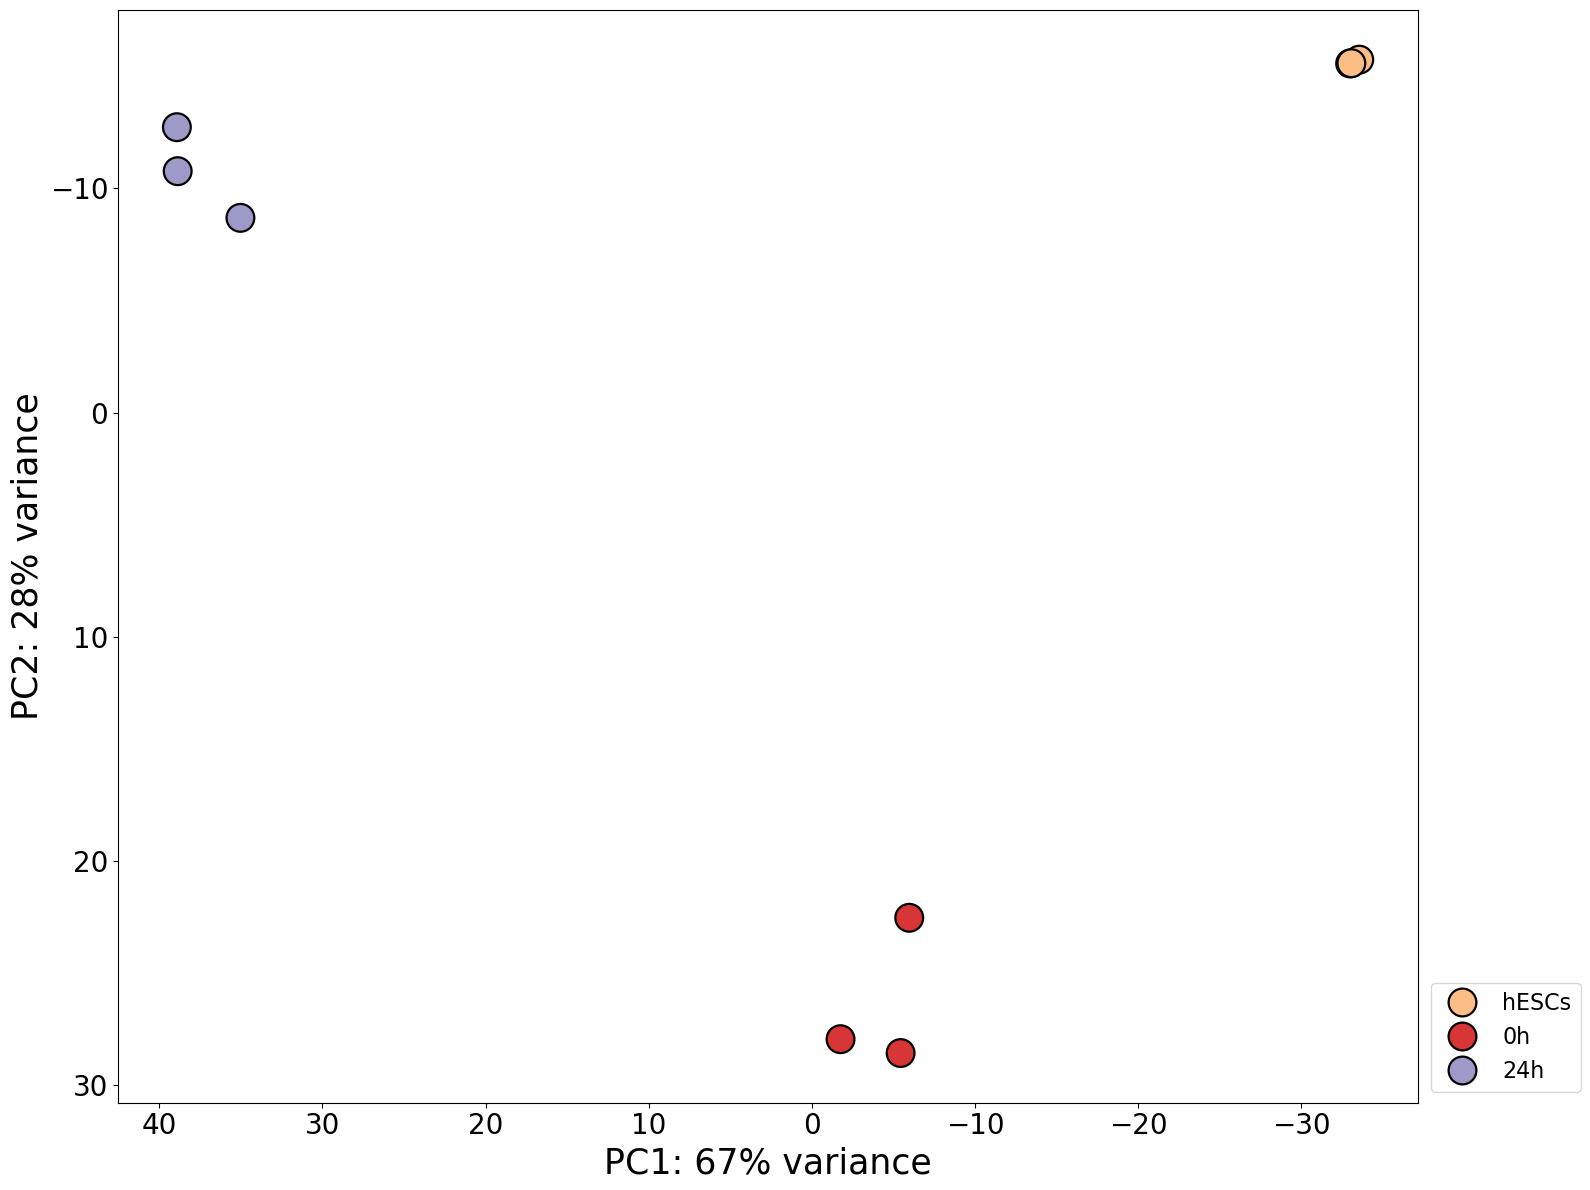

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(16,12))

palette_dict = {
    'hESCs': '#FDBE85',  # light orange
    '0h': "#D83636",     # light red
    '24h': '#9E9AC8'     # light purple
}


sns.scatterplot(
    data=dds.obs,
    x='PC1',
    y='PC2',
    hue=dds.obs.condition,
    palette=palette_dict,
    s=400,
    edgecolor='black',
    ax=ax
)

# Axes labels
ax.set_xlabel(f'PC1: {int(round(pca.explained_variance_ratio_[0]*100))}% variance', fontsize=25)
ax.set_ylabel(f'PC2: {int(round(pca.explained_variance_ratio_[1]*100))}% variance', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.invert_xaxis()
ax.invert_yaxis()

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, prop={'size':16}, loc=(1.01,0.01))

plt.tight_layout()
plt.savefig(f"../results/human_gastruloids_pca_scatterplot.{save_format}", bbox_inches="tight", transparent=True)
plt.show()

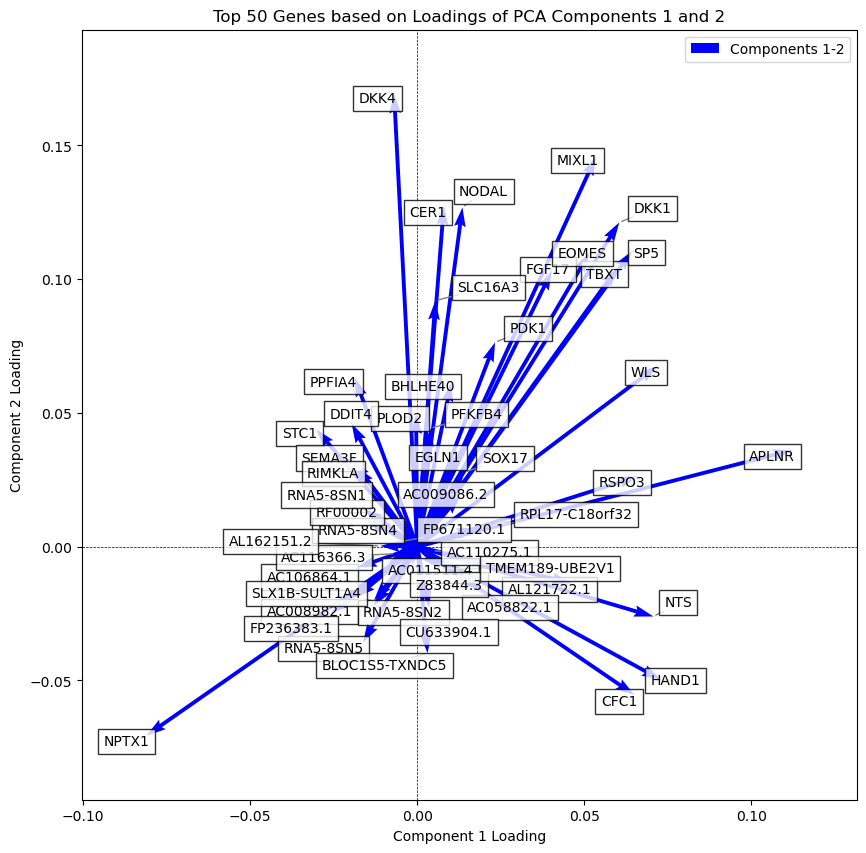

In [94]:
fig,ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,50,ax)

plt.savefig(f"../results/human_gastruloids_analysis_heatmap_50loadings.{save_format}",bbox_inches="tight",transparent=True)

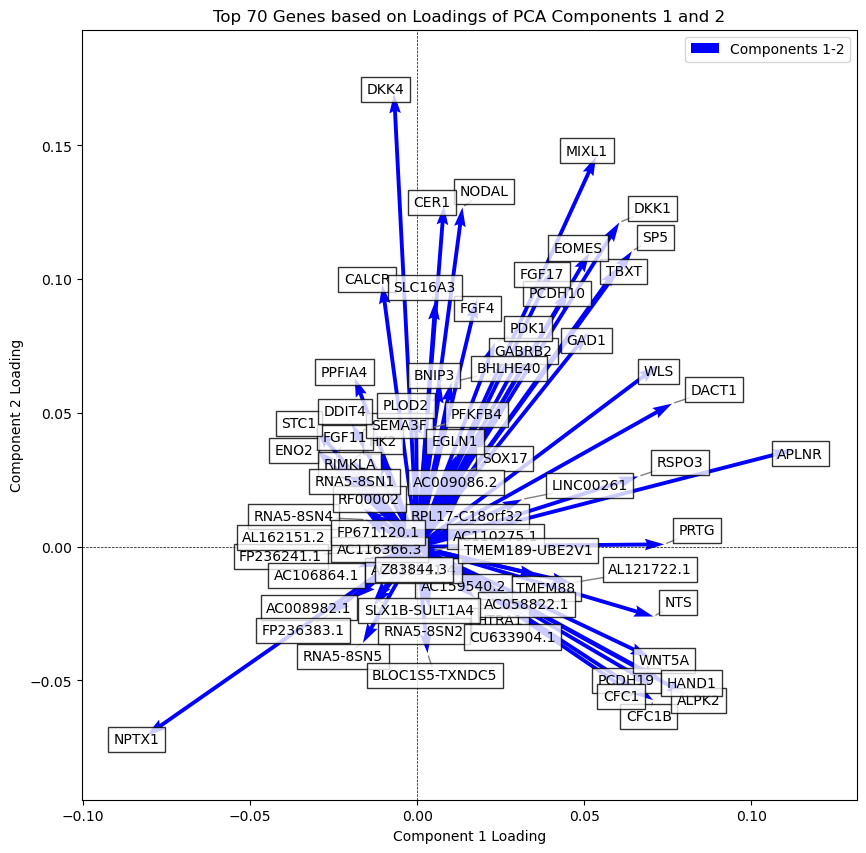

In [95]:
fig,ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,70,ax)

plt.savefig(f"../results/human_gastruloids_analysis_heatmap_70loadings.{save_format}",bbox_inches="tight",transparent=True)

### Heatmaps

In [109]:
gene_groups = {
    "8.2": ['SOX2','ZFP42','OTX2','NANOG','NODAL','EOMES','WNT3','WNT3A','TBXT','CDX1','CDX2','HOXA1','HOXA2'],
    "8.3": ['POU5F1','ZFP42','ESRBB','PECAM1','TFAP2C','KLF5','NR0B1','OTX2','HESX1','SOX2','SOX1','NODAL','WNT3'],
    "8.4": ['NODAL','EOMES','FOXA2','SOX17','LHX1','CHRD'],
    "8.5": ['SOX2','ZFP42','OTX2','NANOG','NODAL','EOMES','FOXA2','SOX17','LHX1','CHRD','WNT3','WNT3A','TBXT','CDX1','CDX2','HOXA1','HOXA2']
}

In [110]:
logdf = np.log1p(counts)
mean_df = logdf.groupby(metadata['condition']).mean()
mean_df = mean_df.loc[["hESCs", "0h", "24h"]]


In [124]:
# --- Function to plot lineplots ---
def plot_lineplot(genes, df, save_path):
    df_subset = df.loc[:, genes]
    plt.figure(figsize=(12, 6))
    palette = sns.color_palette("tab10", n_colors=len(genes))
    for i, gene in enumerate(df_subset.columns):
        plt.plot(df_subset.index, df_subset[gene], marker='o', linestyle='--', linewidth=2, color=palette[i], 
                 label=f"${gene}$", markersize=7)
    plt.ylabel("Log1p Expression")
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
    plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# --- Function to plot heatmap ---
def plot_heatmap(genes, df, save_path):
    df_subset = df.loc[:, genes]  # keep genes as columns
    df_subset = df_subset.T  # genes as rows
    plt.figure(figsize=(6, len(genes)*0.5))
    ax = sns.heatmap(df_subset, cmap='RdYlBu_r', annot=False)

    # Set y-tick labels italic
    ax.set_yticklabels(ax.get_yticklabels(), fontstyle='italic')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()



In [125]:
# --- Generate plots ---
save_dir = '../results/'
os.makedirs(save_dir, exist_ok=True)

for key, gene_list in gene_groups.items():
    gene_list = [g for g in gene_list if g in counts.columns]
    plot_lineplot(gene_list, mean_df, os.path.join(save_dir, f"human_gastruloids_lineplot_{key}.svg"))
    plot_heatmap(gene_list, mean_df, os.path.join(save_dir, f"human_gastruloids_heatmap_{key}.svg"))